In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

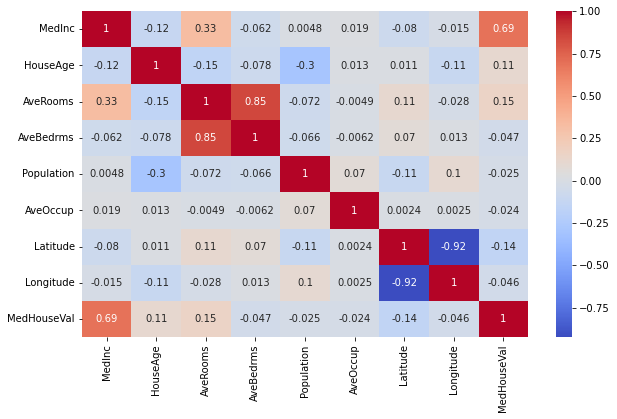

In [3]:
print(df.info())
print(df.describe())

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()


In [17]:
x=df.drop(labels=["MedHouseVal"], axis=1)

In [26]:
y=df[["MedHouseVal"]]

In [32]:
X_train, X_test,y_train, y_test=train_test_split(x, y,test_size=0.2, train_size=0.8, random_state=42)

In [33]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(16512, 8)
(4128, 8)
(16512, 1)
(4128, 1)


In [34]:
scaler=StandardScaler(copy=True, with_mean=True, with_std=True)
X_train_scaled_transformed=scaler.fit_transform(X_train)
X_test_transformed=scaler.transform(X_test)

In [35]:
print(np.mean(X_train_scaled_transformed, axis=0))  # Should be ≈ 0
print(np.std(X_train_scaled_transformed, axis=0))   # Should be ≈ 1


[-6.51933288e-17 -9.25185854e-18 -1.98108110e-16 -1.70729064e-16
 -2.15159501e-19  4.93656580e-17  6.40099515e-17  1.75333477e-15]
[1. 1. 1. 1. 1. 1. 1. 1.]


In [36]:
model=LinearRegression()

In [37]:
model.fit(X_train_scaled_transformed, y_train)

LinearRegression()

In [39]:
y_pred = model.predict(X_test_transformed)


In [44]:
mae=mean_absolute_error(y_test, y_pred)
mae

0.5332001304956566

In [45]:
mse=mean_squared_error(y_test, y_pred)
mse

0.5558915986952444

In [46]:
rmse=np.sqrt(mse)
rmse

0.7455813830127764

In [47]:
r=r2_score(y_test, y_pred)
r


0.5757877060324508

In [49]:
model2=RandomForestRegressor()

In [50]:
model2.fit(X_train, y_train)

C:\Users\mouha\AppData\Local\Temp/ipykernel_24600/3182408575.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model2.fit(X_train, y_train)


RandomForestRegressor()

In [52]:
y_pred2 = model2.predict(X_test)


In [53]:
mae=mean_absolute_error(y_test, y_pred2)


In [54]:
mse=mean_squared_error(y_test, y_pred2)
mse

0.2553338405819292

In [55]:
rmse=np.sqrt(mse)
rmse

0.5053056902330798

In [56]:
r=r2_score(y_test, y_pred2)
r


0.8051495030775119

In [58]:
feature_importances = pd.Series(model2.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False)

MedInc        0.525593
AveOccup      0.139087
Latitude      0.089120
Longitude     0.088543
HouseAge      0.054112
AveRooms      0.043475
Population    0.030608
AveBedrms     0.029462
dtype: float64

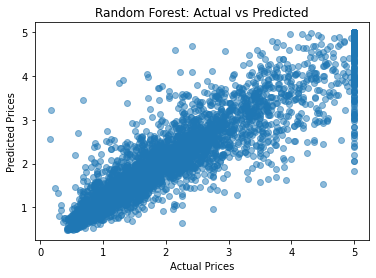

In [62]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred2, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted")
plt.show()


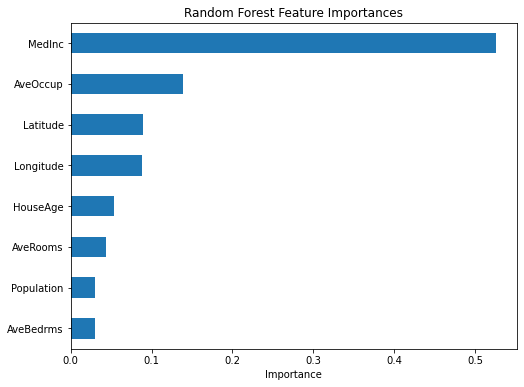

In [63]:
import matplotlib.pyplot as plt

feature_importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()


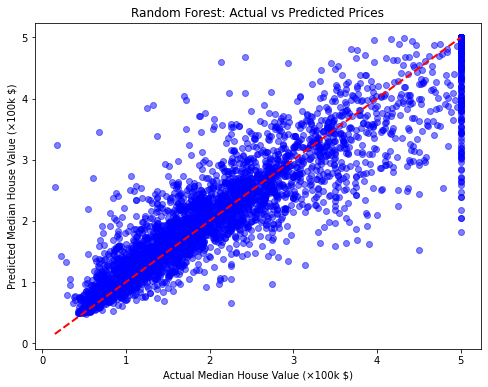

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred2, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel("Actual Median House Value (×100k $)")
plt.ylabel("Predicted Median House Value (×100k $)")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.show()


In [66]:
df["Income_per_Room"] = df["MedInc"] / df["AveRooms"]


In [67]:
df["Rooms_per_Household"] = df["AveRooms"] / df["AveOccup"]


In [70]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df["RegionCluster"] = kmeans.fit_predict(df[["Latitude", "Longitude"]])


MAE: 0.3257139696947676
RMSE: 0.4970582049622993
R2: 0.8114582063898805


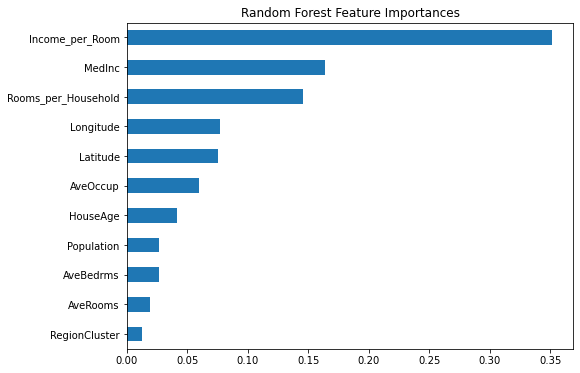

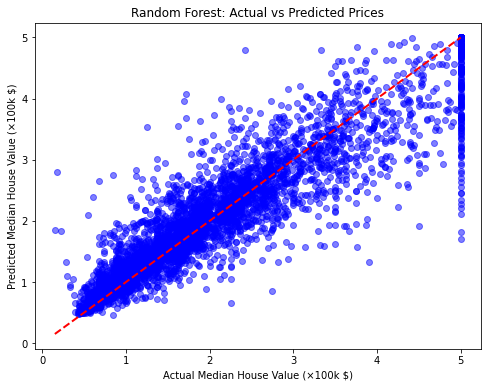

In [72]:



# After creating Income_per_Room, Rooms_per_Household, and RegionCluster
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]




X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 6️⃣ Preprocessing
# -----------------------------
# Identify numerical and categorical features
num_features = ["MedInc","HouseAge","AveRooms","AveBedrms","Population",
                "AveOccup","Latitude","Longitude","Income_per_Room","Rooms_per_Household"]
cat_features = ["RegionCluster"]  # can stay as integer for Random Forest

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features)
        # no encoding for RF, leave cat as is
    ],
    remainder='passthrough'  # keep RegionCluster
)

# -----------------------------
# 7️⃣ Pipeline
# -----------------------------
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

# -----------------------------
# 8️⃣ Train Model
# -----------------------------
pipeline.fit(X_train, y_train)

# -----------------------------
# 9️⃣ Predict
# -----------------------------
y_pred = pipeline.predict(X_test)

# -----------------------------
# 🔹 Evaluate
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# -----------------------------
# 🔹 Feature Importance
# -----------------------------
# Extract feature importances from Random Forest
model = pipeline.named_steps["model"]

# Because we used ColumnTransformer, numerical features are first 10, RegionCluster is last
feature_names = num_features + cat_features
importances = pd.Series(model.feature_importances_, index=feature_names)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Random Forest Feature Importances")
plt.show()

# -----------------------------
# 🔹 Actual vs Predicted Plot
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Median House Value (×100k $)")
plt.ylabel("Predicted Median House Value (×100k $)")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.show()


MAE: 0.2941672917980487
RMSE: 0.45507607568433894
R2: 0.8419621369366206


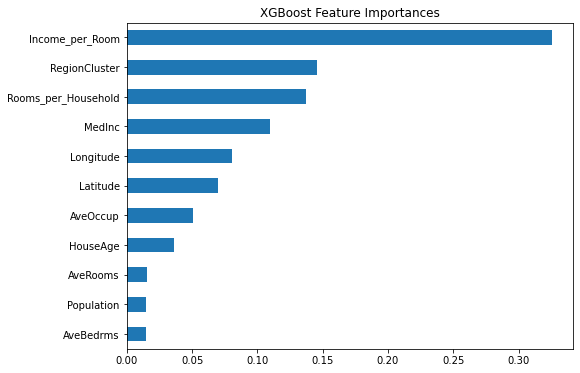

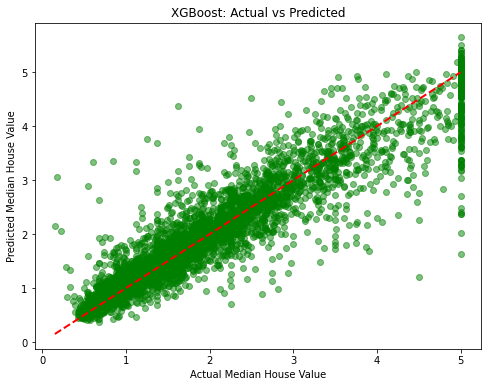

In [79]:

import xgboost as xgb


# -----------------------------
# 5️⃣ Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 6️⃣ Train XGBoost Regressor
# -----------------------------
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.2,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# -----------------------------
# 7️⃣ Predict
# -----------------------------
y_pred = xgb_model.predict(X_test)

# -----------------------------
# 8️⃣ Evaluate
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# -----------------------------
# 9️⃣ Feature Importance
# -----------------------------
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("XGBoost Feature Importances")
plt.show()

# -----------------------------
# 🔹 Actual vs Predicted Plot
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("XGBoost: Actual vs Predicted")
plt.show()


In [80]:
from sklearn.model_selection import cross_val_score, KFold


In [81]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.2,
    random_state=42
)


In [82]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)


In [83]:
cv_scores = cross_val_score(xgb_model, X, y, cv=kf, scoring='r2')
print("R² scores for each fold:", cv_scores)
print("Mean R²:", np.mean(cv_scores))
print("Std of R²:", np.std(cv_scores))


R² scores for each fold: [0.84472987 0.8470017  0.83459116 0.85285643 0.84221147]
Mean R²: 0.8442781251123066
Std of R²: 0.00598861528417409


In [84]:
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
rmse_scores = []


In [85]:
for lr in learning_rates:
    model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=lr,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_scores.append(rmse)


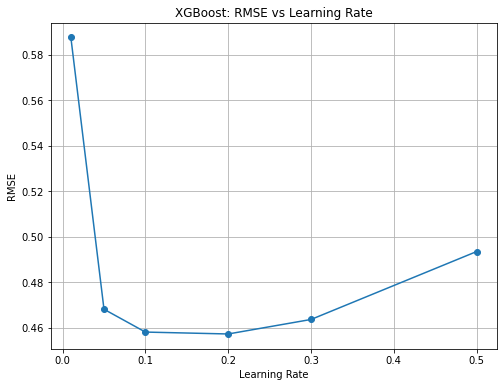

In [86]:
plt.figure(figsize=(8,6))
plt.plot(learning_rates, rmse_scores, marker='o', linestyle='-')
plt.xlabel("Learning Rate")
plt.ylabel("RMSE")
plt.title("XGBoost: RMSE vs Learning Rate")
plt.grid(True)
plt.show()
